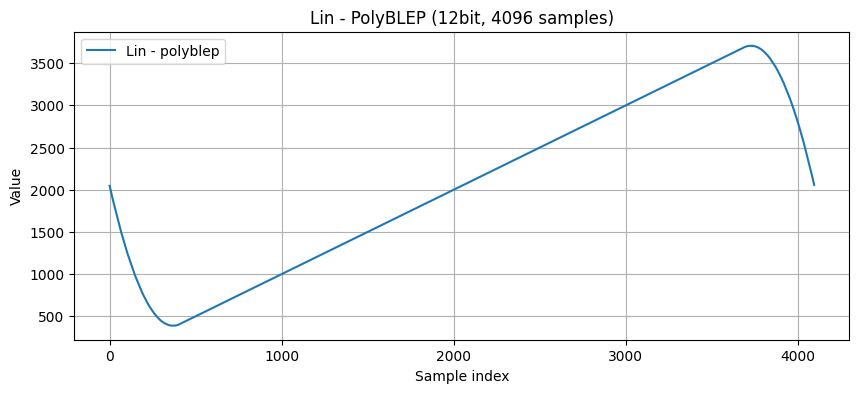

In [9]:
import re
import numpy as np
import matplotlib.pyplot as plt

def load_c_array(filename):
    """Cのヘッダファイルから配列を読み込む"""
    with open(filename, "r") as f:
        content = f.read()
    # { ... } の中身を取り出す
    match = re.search(r"\{(.*?)\}", content, re.S)
    if not match:
        raise ValueError("配列データが見つかりません")
    data_str = match.group(1)
    # 数字だけ抽出してリスト化
    data = [int(x.strip()) for x in data_str.split(",") if x.strip()]
    return np.array(data, dtype=np.int32)

# ヘッダファイル読み込み
polyblep = load_c_array("polyblep_12bit_4096.h")

linear = np.arange(4096, dtype=np.int32)
# sine = load_c_array("sine_12bit_4096.h")

# データ長を確認
if len(polyblep) != 4096 or len(linear) != 4096:
    raise ValueError("配列の長さが4096ではありません")

# 差分計算
diff = linear - polyblep

# グラフ表示
plt.figure(figsize=(10,4))
plt.plot(diff, label="Lin - polyblep")
plt.title("Lin - PolyBLEP (12bit, 4096 samples)")
plt.xlabel("Sample index")
plt.ylabel("Value")
plt.grid(True)
plt.legend()
plt.show()
